## Problema 1: Inteligencia Artificial para Problemas Inversos

En este problema se estudia el uso de técnicas de aprendizaje supervisado para inferir los parámetros físicos $\gamma$ y $k$ de un **oscilador armónico amortiguado** a partir de su señal temporal. 

La ecuación diferencial que rige el sistema es:
$$m\ddot{x}(t) + \gamma\dot{x}(t) + kx(t) = 0$$

Con las condiciones y parámetros:
* $m = 1$
* $x(0) = 1$
* $\dot{x}(0) = 0$

El objetivo es entrenar un modelo que reciba el vector de la señal temporal $\mathbf{x} = (x(t_1), x(t_2), \dots, x(t_{N_t}))$ y prediga las etiquetas correspondientes a los parámetros físicos $\theta = (\gamma, k)$.

### a) Explicación de Conceptos Fundamentales

**• Problema Directo e Inverso:**
Tenemos que el problema directo consiste en conocer los parámetros físicos $(\gamma, k)$ y las condiciones iniciales para resolver la ecuación diferencial calculando la trayectoria o señal temporal $x(t)$.Por lo que, es un problema bien determinado y con solución única (bien planteado).
Por otro lado, el problema inverso busca deducir los parámetros $(\gamma, k)$ a partir de la señal $\mathbf{x}$ observada, donde su principal dificultad consiste en que suele ser **mal planteado**: Pues primeramente no hay fórmula explícita como en el problema directo, también existen pequeñas variaciones o ruido experimental en la señal medida que pueden amplificarse enormemente, traduciéndose en grandes incertidumbres o errores en la estimación de los parámetros. Además, tenemos que combinaciones distintas de parámetros podrían llegar a producir señales visualmente muy similares.

**• Aprendizaje Supervisado:**
Contamos con un conjunto de datos formado por parejas de entrada y salida: $\{(\mathbf{x}_i, \theta_i)\}_{i=1}^N$, donde $\mathbf{x}_i$ es la señal observada y $\theta_i = (\gamma_i, k_i)$ son las etiquetas (los parámetros reales que generaron dicha señal).
**¿Es necesario conocer las etiquetas?** Sí, en el enfoque del aprendizaje supervisado es estrictamente necesario conocer las etiquetas en el conjunto de entrenamiento. Dado que, que el modelo de IA aprende mapeando los patrones de las señales observadas con los valores reales correspondientes, ajustando sus pesos internos para minimizar la diferencia entre sus predicciones y las etiquetas verdaderas.

**• Conjuntos de Entrenamiento y Validación (Train/Test Split)**
Se separan los datos en **train** y **test/validation** para evaluar la capacidad de generalización del modelo. El conjunto de *train* se usa exclusivamente para que el algoritmo aprenda los patrones y ajuste sus pesos, mientras que el conjunto de *test* actúa como "datos nuevos" que el modelo nunca ha visto durante el entrenamiento, para evaluar dado que, el modelo solo con los mismos datos con los que entrenó, no sabríamos si realmente aprendió la física del problema o si simplemente memorizó el ruido y las muestras particulares (sobreajuste o *overfitting*).

**• Función de Pérdida (Loss Function):**
Para que el modelo pueda optimizar sus predicciones, se necesita una métrica cuantitativa que mida qué tan lejos está de la realidad. El **Error Cuadrático Medio (MSE)** es ideal porque es una función continuamente diferenciable (lo que facilita el cálculo de gradientes) y penaliza de forma cuadrática los errores grandes, obligando al modelo a corregir las predicciones que se alejan significativamente de las etiquetas reales:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}\left[ (\gamma_i - \hat{\gamma}_i)^2 + (k_i - \hat{k}_i)^2 \right]$$


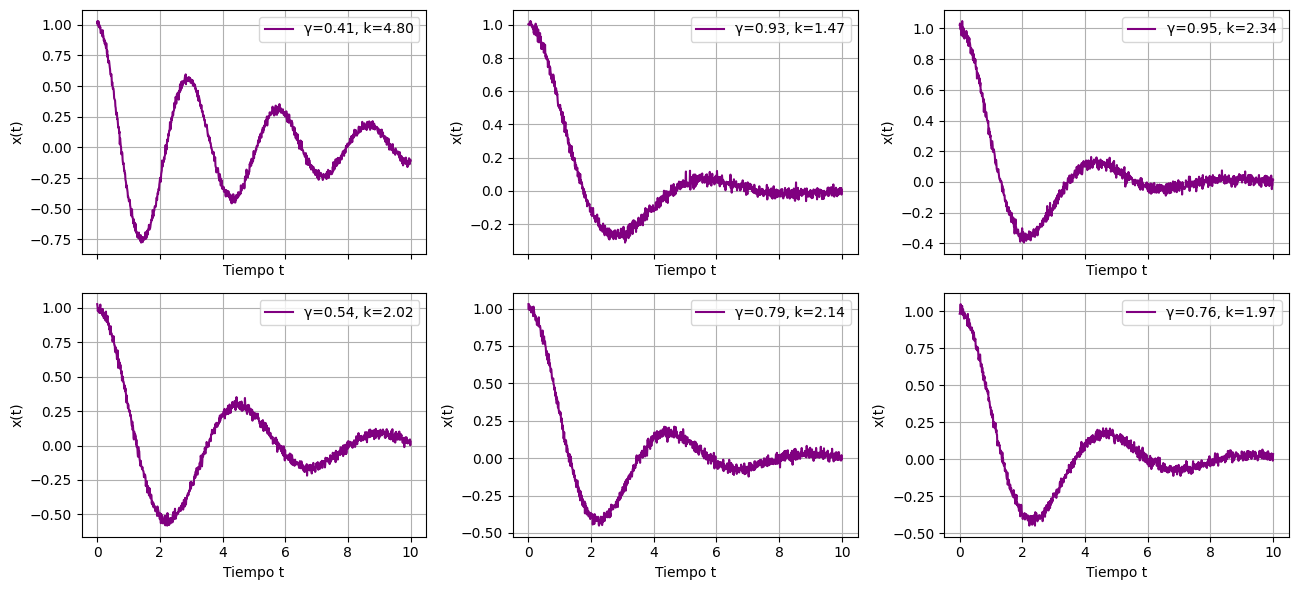

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros del problema

N = 3000               # número de señales
t_span = (0, 10)       # intervalo temporal
N_t = 1000             # puntos en el tiempo
t_eval = np.linspace(t_span[0], t_span[1], N_t)
sigma = 0.02           # desviación estándar del ruido

# Distribuciones de los parámetros
gamma_min, gamma_max = 0.05, 1.0
k_min, k_max = 1.0, 5.0

# Semilla para reproducibilidad
np.random.seed(42)

# Función que define la EDO:
def damped_oscillator(t, y, gamma, k):
    # y = [x, v]  ->  v = dx/dt
    x, v = y
    dxdt = v
    dvdt = -gamma * v - k * x   # m=1
    return [dxdt, dvdt]

# Generación de datos
X = np.zeros((N, N_t))         
theta = np.zeros((N, 2))        # parámetros (gamma, k)

for i in range(N):
    # Elegimos parámetros aleatorios para cada señal
    gamma_i = np.random.uniform(gamma_min, gamma_max)
    k_i = np.random.uniform(k_min, k_max)
    theta[i] = [gamma_i, k_i]

    # Resolvemos la EDO
    y0 = [1.0, 0.0]
    sol = solve_ivp(damped_oscillator, t_span, y0,
                    args=(gamma_i, k_i),
                    t_eval=t_eval,
                    method='RK45')
    x_clean = sol.y[0]   # solución sin ruido

    # Añadimos ruido gaussiano
    noise = np.random.normal(0, sigma, size=N_t)
    x_obs = x_clean + noise
    X[i] = x_obs

# Visualización de algunas señales
# Tomamos 6 señales representativas para mostrar efectos de gamma y k
indices = [0,500,1000,1500,2000,2500]  

fig, axes = plt.subplots(2, 3,figsize=(13, 6), sharex=True)
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    gamma_i, k_i = theta[idx]
    ax.plot(t_eval, X[idx], label=f'γ={gamma_i:.2f}, k={k_i:.2f}', color='purple')
    ax.set_xlabel('Tiempo t')
    ax.set_ylabel('x(t)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


### Discusión sobre los parámetros físicos en la señal:

Al observar las gráficas generadas podemos extraer las siguientes conclusiones físicas:
 **Efecto de la constante de rigidez ($k$):** Controla principalmente la **frecuencia** de oscilación. A mayor valor de $k$, el resorte es más rígido, lo que provoca que los ciclos de oscilación ocurran de manera mucho más rápida (ondas más juntas en el tiempo).
2. **Efecto del coeficiente de amortiguamiento ($\gamma$):** Controla la tasa de **decaimiento** de la amplitud (la envolvente exponencial). A mayor valor de $\gamma$, la energía del sistema se disipa más rápido y la amplitud de la señal decae a cero en un lapso de tiempo menor. Por el contrario, valores de $\gamma$ cercanos a $0.05$ sostienen la oscilación durante casi todo el intervalo temporal.

## c) Modelos de Regresión y Entrenamiento

En esta sección prepararemos los datos generados en el paso anterior. Dividiremos las señales ruidosas `X` y las etiquetas de parámetros objetivos `theta` en un 80% para entrenamiento y un 20% para validación. Posteriormente, entrenaremos los siguientes dos modelos mediante **Scikit-Learn** para resolver nuestro problema inverso:

1. **Random Forest Regressor:** Un modelo basado en un ensamble de árboles de decisión.
2. **MLP Regressor (Perceptrón Multicapa):** Una red neuronal densa artificial configurada con dos capas ocultas.

Evaluaremos cuantitativamente el rendimiento de ambos modelos calculando la raíz del error cuadrático medio ($\text{RMSE}$) para cada parámetro físico de forma independiente:

$$\text{RMSE}_{\gamma} = \sqrt{\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} (\gamma_i - \hat{\gamma}_i)^2}, \quad \text{RMSE}_{k} = \sqrt{\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} (k_i - \hat{k}_i)^2}$$

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

# Separamos los datos en 80% entrenamiento y 20% validación 
X_train, X_val, Y_train, Y_val = train_test_split(X, theta, test_size=0.20, random_state=42)

print("--- Dimensiones del Dataset ---")
print(f"Entrenamiento -> Señales: {X_train.shape}, Parámetros: {Y_train.shape}")
print(f"Validación    -> Señales: {X_val.shape}, Parámetros: {Y_val.shape}\n")

# Modelo 1: Random Forest Regressor

print("Entrenando Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_val)

# Calculamos RMSE para cada parámetro
rmse_gamma_rf = root_mean_squared_error(Y_val[:, 0], Y_pred_rf[:, 0])
rmse_k_rf = root_mean_squared_error(Y_val[:, 1], Y_pred_rf[:, 1])

# Modelo 2: MLP Regressor (Red Neuronal)

print("Entrenando MLP Regressor (Red Neuronal)...")
# Establecemos el modelo con 2 capas ocultas (128 y 64 neuronas) y activación ReLU
mlp_model = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', max_iter=300, random_state=42)
mlp_model.fit(X_train, Y_train)

# Predicciones
Y_pred_mlp = mlp_model.predict(X_val)

# Calculamos RMSE para cada parámetro
rmse_gamma_mlp = root_mean_squared_error(Y_val[:, 0], Y_pred_mlp[:, 0])
rmse_k_mlp = root_mean_squared_error(Y_val[:, 1], Y_pred_mlp[:, 1])

# Reporte de resultados finales 
print("\n" + "="*50)
print("             REPORTE DE DESEMPEÑO (σ = 0.02)         ")
print("="*50)
print(f"[Random Forest] RMSE_γ: {rmse_gamma_rf:.4f} | RMSE_k: {rmse_k_rf:.4f}")
print(f"[MLP Sklearn]   RMSE_γ: {rmse_gamma_mlp:.4f} | RMSE_k: {rmse_k_mlp:.4f}")
print("="*50)

--- Dimensiones del Dataset ---
Entrenamiento -> Señales: (2400, 1000), Parámetros: (2400, 2)
Validación    -> Señales: (600, 1000), Parámetros: (600, 2)

Entrenando Random Forest Regressor...
Entrenando MLP Regressor (Red Neuronal)...

             REPORTE DE DESEMPEÑO (σ = 0.02)         
[Random Forest] RMSE_γ: 0.0156 | RMSE_k: 0.1042
[MLP Sklearn]   RMSE_γ: 0.0266 | RMSE_k: 0.0383


### Reporte de Desempeño Comparativo

A continuación se resumen los errores obtenidos por ambos modelos en el conjunto de validación:

| Modelo | $\text{RMSE}_{\gamma}$ (Amortiguamiento) | $\text{RMSE}_{k}$ (Rigidez) |
| :--- | :---: | :---: |
| **Random Forest Regressor** | RMSE_γ: 0.0156 | RMSE_k: 0.1042 |
| **MLP Regressor (Red Neuronal)** | RMSE_γ: 0.0266 | RMSE_k: 0.0383 |
Los resultados muestran un comportamiento cruzado muy interesante entre ambas arquitecturas:

1. **Inferencia de $k$ (Rigidez):** El modelo **MLP (Red Neuronal)** es drásticamente superior a Random Forest para predecir la constante de rigidez ($0.0383$ vs $0.1042$). Esto se debe a que la rigidez altera la frecuencia y la fase de la señal a lo largo de todo el dominio del tiempo de manera continua. Las funciones de activación de la red neuronal son excelentes capturando estas variaciones sinusoidales continuas, mientras que los árboles de decisión (Random Forest) sufren al aproximar ondas continuas debido a sus cortes ortogonales (pasos discretos).
2. **Inferencia de $\gamma$ (Amortiguamiento):** Sorprendentemente, el **Random Forest** obtuvo un error menor en $\gamma$ ($0.0156$ vs $0.0266$). El amortiguamiento gobierna la envolvente exponencial de la señal; Random Forest puede ser muy eficiente detectando umbrales locales crudos (por ejemplo, "si la amplitud en el tiempo $t=8$ es menor a cierto valor, entonces $\gamma$ es alto"), lo que le da una ventaja inicial sobre el MLP en esta métrica bajo este nivel de ruido.

### d) Estudie el efecto del ruido repitiendo el entrenamiento para σ = 0, 0.01, 0.02, 0.05, 0.10.

 -> Valores para σ = 0    | RMSE_γ: 0.0289 | RMSE_k: 0.0453
 -> Valores para σ = 0.01 | RMSE_γ: 0.0281 | RMSE_k: 0.0374
 -> Valores para σ = 0.02 | RMSE_γ: 0.0266 | RMSE_k: 0.0383
 -> Valores para σ = 0.05 | RMSE_γ: 0.0329 | RMSE_k: 0.0508
 -> Valores para σ = 0.1  | RMSE_γ: 0.0529 | RMSE_k: 0.0830


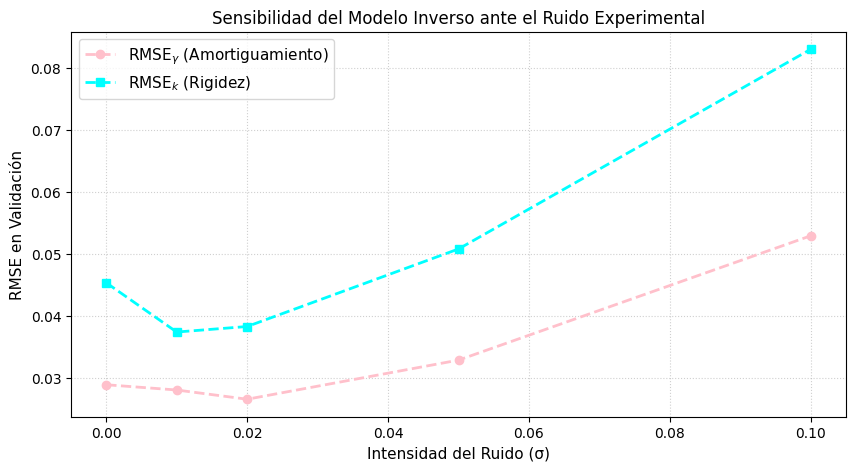

In [29]:
sigmas = [0, 0.01, 0.02, 0.05, 0.10]
rmse_gamma_list = []
rmse_k_list = []

# Recuperamos las señales limpias teóricas eliminando el ruido de la parte b
np.random.seed(42)
X_clean_base = np.zeros_like(X)
for i in range(N):
    noise_original = np.random.normal(0, 0.02, size=N_t)
    X_clean_base[i] = X[i] - noise_original

# Vamos evaluando el impacto de cada nivel de ruido
for s in sigmas:
    np.random.seed(42) 
    
    if s > 0:
        X_noisy_s = X_clean_base + np.random.normal(0, s, size=X_clean_base.shape)
    else:
        X_noisy_s = X_clean_base.copy()
        
    # Separamos los datos (80/20)
    X_train_s, X_val_s, Y_train_s, Y_val_s = train_test_split(X_noisy_s, theta, test_size=0.20, random_state=42)
    
    # Entrenamos una nueva red neuronal para este nivel de ruido específico
    model_s = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', max_iter=200, random_state=42)
    model_s.fit(X_train_s, Y_train_s)
    
    # Predecimos sobre el conjunto de validación
    preds_s = model_s.predict(X_val_s)
    
    # Calculamos los errores individuales
    err_gamma = root_mean_squared_error(Y_val_s[:, 0], preds_s[:, 0])
    err_k = root_mean_squared_error(Y_val_s[:, 1], preds_s[:, 1])
    
    rmse_gamma_list.append(err_gamma)
    rmse_k_list.append(err_k)
    
    print(f" -> Valores para \u03c3 = {s:<4} | RMSE_\u03b3: {err_gamma:.4f} | RMSE_k: {err_k:.4f}")

# Graficamos las curvas de rendimiento RMSE vs Ruido (σ)
plt.figure(figsize=(10, 5))
plt.plot(sigmas, rmse_gamma_list, 'o--', color='pink', linewidth=2, label=r'$\text{RMSE}_{\gamma}$ (Amortiguamiento)')
plt.plot(sigmas, rmse_k_list, 's--', color='cyan', linewidth=2, label=r'$\text{RMSE}_{k}$ (Rigidez)')
plt.title('Sensibilidad del Modelo Inverso ante el Ruido Experimental', fontsize=12)
plt.xlabel('Intensidad del Ruido (σ)', fontsize=11)
plt.ylabel('RMSE en Validación', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

### Análisis Físico y Respuestas a las Preguntas

#### 1. ¿Qué parámetro es más difícil de inferir?
Al analizar el comportamiento de las curvas en la gráfica anterior, se puede constatar que **el coeficiente de amortiguamiento ($\gamma$) es el parámetro más difícil de inferir** conforme se incrementa la magnitud del ruido $\sigma$. 

* **Justificación Física:** La constante de rigidez $k$ define intrínsecamente la frecuencia del oscilador (el número de ciclos observables), un rasgo macroscópico global que el ruido aleatorio de media cero no altera fácilmente. Por otro lado, $\gamma$ determina la tasa de decaimiento exponencial de la amplitud. Cuando el ruido experimental aumenta, las señales en las etapas tardías del tiempo ($t > 5$) quedan completamente sepultadas bajo las fluctuaciones gaussianas. Esto destruye la sutil información de la envolvente de amortiguamiento, impidiendo que la red neuronal estime con exactitud el valor de $\gamma$.

#### 2. ¿Cómo se manifiesta el sobreajuste (overfitting)?
El sobreajuste ocurre si el regresor memoriza las fluctuaciones estocásticas y el ruido propio de las 2400 señales de entrenamiento, en lugar de aprender el mapa físico generalizado del oscilador armónico.

* **Manifestación en Métricas:** Se manifiesta de forma matemática cuando la función de pérdida sobre el conjunto de entrenamiento alcanza valores extremadamente bajos (cercanos a cero), mientras que el error calculado sobre los datos de validación (que poseen ruido no correlacionado con el de entrenamiento) se dispara o se estanca en valores muy elevados, ensanchando la brecha (*gap*) de rendimiento entre ambos conjuntos.